# IDIL — Machine Learning Analysis

## Project focus
**Main Research Question:**  
How does marketing intensity affect a song’s long-term streaming performance, and is there evidence of diminishing marginal returns?

**Additional Questions**
1. Which factors are most important for predicting long-term streaming success?
2. How do audio characteristics interact with marketing intensity?
3. Can nonlinear ML models improve the prediction of long-term streams?

### Important interpretation rule
`marketing_budget` is a **relative marketing-spend index**, not euros or another currency.

### Main modelling choice
The main target is `streams_3yr`, transformed as `log1p(streams_3yr)` because the raw target is extremely right-skewed.

Post-release variables such as `first_month_streams`, `playlist_adds_first_month`, `editorial_playlist`, and `tiktok_virality` are excluded from the main marketing model to avoid using information that becomes available only after release.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Load data
from pathlib import Path

# Find the dataset either next to the notebook or in /mnt/data
candidates = [
    Path("raw-data/song_longevity.csv"),
    Path("song_longevity(1).csv"),
    Path("song_longevity.csv"),
    Path("/mnt/data/song_longevity(1).csv"),
    Path("/mnt/data/song_longevity.csv")
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find song_longevity CSV. Put it in the same folder as this notebook.")

df = pd.read_csv(data_path)

print("Dataset loaded:", df.shape)


Dataset loaded: (45000, 21)


## Step 1 — Load and Understand the Data

We first inspect the dataset structure, variable types, descriptive statistics, target variable, and modelling predictors.


In [2]:
target = "streams_3yr"

predictors = [
    "marketing_budget",
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "instrumentalness",
    "tempo_bpm",
    "song_length_sec",
    "artist_prior_monthly_listeners",
    "featured_artist",
    "genre",
    "label_tier"
]

post_release_variables = [
    "first_month_streams",
    "playlist_adds_first_month",
    "editorial_playlist",
    "tiktok_virality"
]

print("DATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nFIRST 5 ROWS")
display(df.head())

print("\nDESCRIPTIVE STATISTICS")
display(df.describe(include="all").T)

print("\nTARGET SUMMARY")
print(df[target].describe())


DATASET SHAPE
(45000, 21)

COLUMN NAMES
['track_id', 'genre', 'energy', 'valence', 'danceability', 'acousticness', 'instrumentalness', 'tempo_bpm', 'song_length_sec', 'label_tier', 'marketing_budget', 'playlist_adds_first_month', 'editorial_playlist', 'tiktok_virality', 'artist_prior_monthly_listeners', 'featured_artist', 'first_month_streams', 'halflife_days', 'streams_3yr', 'slow_burner', 'is_hit']

DATA TYPES
track_id                           object
genre                              object
energy                            float64
valence                           float64
danceability                      float64
acousticness                      float64
instrumentalness                  float64
tempo_bpm                           int64
song_length_sec                     int64
label_tier                         object
marketing_budget                  float64
playlist_adds_first_month           int64
editorial_playlist                  int64
tiktok_virality                   floa

,track_id,genre,energy,valence,danceability,acousticness,instrumentalness,tempo_bpm,song_length_sec,label_tier,marketing_budget,playlist_adds_first_month,editorial_playlist,tiktok_virality,artist_prior_monthly_listeners,featured_artist,first_month_streams,halflife_days,streams_3yr,slow_burner,is_hit
0,TRK000000,edm,5.95,2.39,9.71,2.08,2.59,144,167,independent,0.87,1,0,1.42,6700.0,0,15850,59,53300,0,0
1,TRK000001,edm,4.70,4.50,5.14,3.26,2.20,153,156,major,1.62,4,1,1.01,277000.0,0,159360,67,975600,0,1
2,TRK000002,country,8.41,8.51,7.53,6.97,2.85,142,282,indie_label,0.08,7,0,1.53,25800.0,0,1990,102,11400,0,0
3,TRK000003,latin,1.66,5.50,5.06,3.58,0.29,102,240,major,1.64,12,0,0.16,2400.0,0,92650,14,24600,0,0
4,TRK000004,hiphop,5.19,3.64,5.64,3.64,4.24,132,224,independent,1.29,1,0,0.50,9800.0,0,5260,57,26000,0,0



DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,45000,45000,TRK000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,45000,8,hiphop,8977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,45000.0,NaN,NaN,NaN,5.986405,1.960802,0.0,4.65,6.0,7.35,10.0
valence,45000.0,NaN,NaN,NaN,4.993783,2.155279,0.0,3.51,4.99,6.49,10.0
danceability,45000.0,NaN,NaN,NaN,5.974807,1.949158,0.0,4.64,5.99,7.3225,10.0
acousticness,45000.0,NaN,NaN,NaN,4.039318,2.366662,0.0,2.3,3.98,5.69,10.0
instrumentalness,45000.0,NaN,NaN,NaN,1.937174,1.682567,0.0,0.71,1.48,2.6725,10.0
tempo_bpm,45000.0,NaN,NaN,NaN,119.881867,24.854395,60.0,103.0,120.0,137.0,200.0
song_length_sec,45000.0,NaN,NaN,NaN,199.759244,45.028496,60.0,170.0,200.0,230.0,388.0
label_tier,45000,3,independent,18724,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TARGET SUMMARY
count    4.500000e+04
mean     6.130499e+05
std      5.399919e+06
min      1.000000e+02
25%      1.300000e+04
50%      5.150000e+04
75%      2.144000e+05
max      6.130682e+08
Name: streams_3yr, dtype: float64


### Step 1 finding

The dataset contains **45,000 songs and 21 variables**. Each row represents one unique track.  
The raw three-year streaming target is highly uneven: the median is approximately **51.5K streams**, the mean is approximately **613K**, and the maximum exceeds **613M**. This motivates checking the target for severe right-skewness before modelling.


## Step 2 — Data Quality and Preprocessing

We check missing values, duplicate track IDs, categorical values, binary variables, and skewness.  
Only transformations that are clearly justified are applied.


In [3]:
print("MISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATED TRACK IDs")
print(df["track_id"].duplicated().sum())

print("\nGENRE VALUES")
print(df["genre"].value_counts())

print("\nLABEL TIER VALUES")
print(df["label_tier"].value_counts())

binary_columns = [
    "featured_artist",
    "editorial_playlist",
    "slow_burner",
    "is_hit"
]

print("\nBINARY VARIABLE VALUES")
for col in binary_columns:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())

# Log transformations
df["log_streams_3yr"] = np.log1p(df["streams_3yr"])
df["log_artist_prior_listeners"] = np.log1p(df["artist_prior_monthly_listeners"])

print("\nSKEWNESS COMPARISON")
print("streams_3yr:", round(df["streams_3yr"].skew(), 2))
print("log_streams_3yr:", round(df["log_streams_3yr"].skew(), 2))
print("artist_prior_monthly_listeners:", round(df["artist_prior_monthly_listeners"].skew(), 2))
print("log_artist_prior_listeners:", round(df["log_artist_prior_listeners"].skew(), 2))


MISSING VALUES
track_id                          0
genre                             0
energy                            0
valence                           0
danceability                      0
acousticness                      0
instrumentalness                  0
tempo_bpm                         0
song_length_sec                   0
label_tier                        0
marketing_budget                  0
playlist_adds_first_month         0
editorial_playlist                0
tiktok_virality                   0
artist_prior_monthly_listeners    0
featured_artist                   0
first_month_streams               0
halflife_days                     0
streams_3yr                       0
slow_burner                       0
is_hit                            0
dtype: int64

DUPLICATED TRACK IDs
0

GENRE VALUES
genre
hiphop     8977
pop        8886
latin      5415
edm        5399
indie      4573
rock       4508
rnb        3666
country    3576
Name: count, dtype: int64

LABEL TIER VALUES

### Step 2 finding

- No missing values were found.
- No duplicated track IDs were found.
- `streams_3yr` skewness fell from **53.22 to 0.15** after the log transformation.
- `artist_prior_monthly_listeners` skewness fell from **40.72 to 0.12** after the log transformation.

Therefore, `log_streams_3yr` is used as the regression target and `log_artist_prior_listeners` replaces the raw listener count in the model.


## Step 3 — Exploratory Analysis

We examine the target distribution, the relationship between marketing intensity and long-term streams, and correlations among numerical modelling variables.


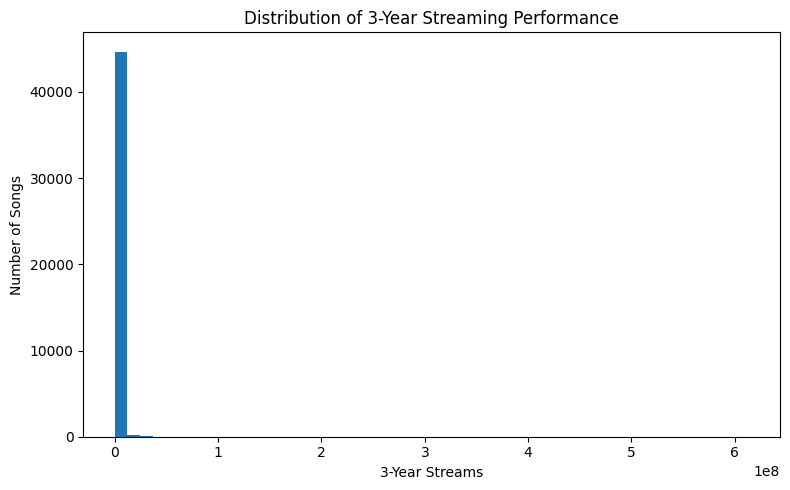

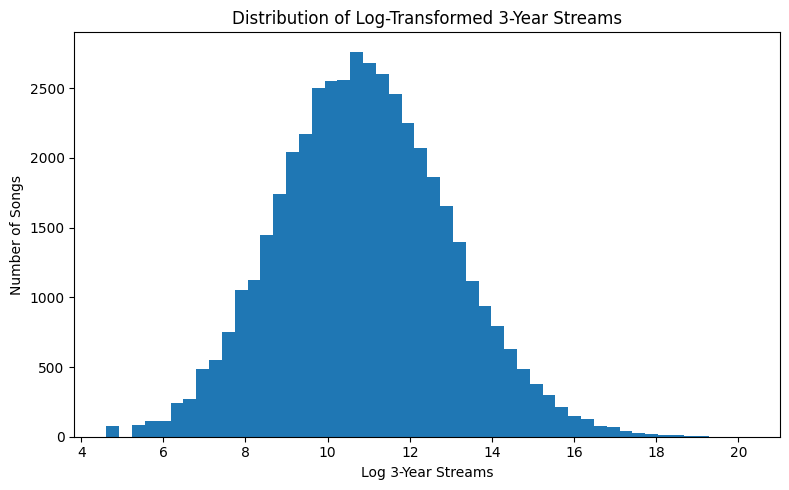

In [4]:
# Raw target distribution
plt.figure(figsize=(8, 5))
plt.hist(df["streams_3yr"], bins=50)
plt.xlabel("3-Year Streams")
plt.ylabel("Number of Songs")
plt.title("Distribution of 3-Year Streaming Performance")
plt.tight_layout()
plt.show()

# Log target distribution
plt.figure(figsize=(8, 5))
plt.hist(df["log_streams_3yr"], bins=50)
plt.xlabel("Log 3-Year Streams")
plt.ylabel("Number of Songs")
plt.title("Distribution of Log-Transformed 3-Year Streams")
plt.tight_layout()
plt.show()


CORRELATION BETWEEN MARKETING BUDGET AND LOG 3-YEAR STREAMS
0.213


,marketing_budget_group,number_of_songs,avg_marketing_budget,median_streams_3yr,avg_log_streams_3yr
0,Very Low,9088,0.332828,27300.0,10.269182
1,Low,9013,0.833194,41000.0,10.663787
2,Medium,9006,1.306322,52100.0,10.906309
3,High,8936,1.948480,62850.0,11.128929
4,Very High,8957,3.521187,99000.0,11.561323


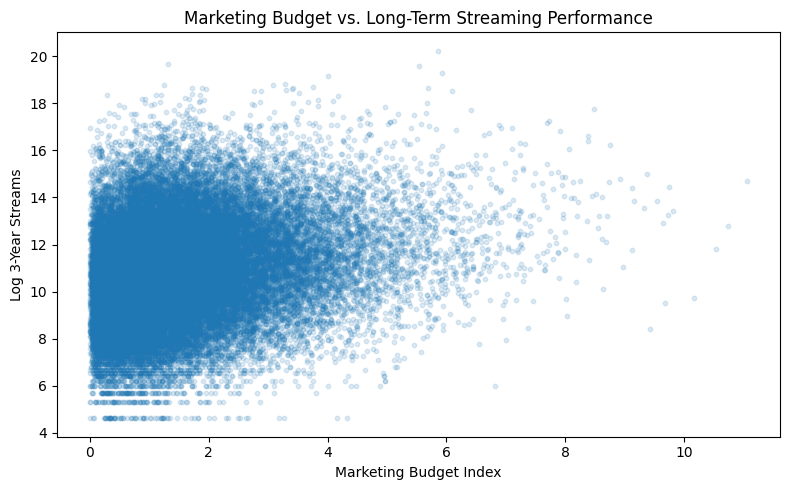

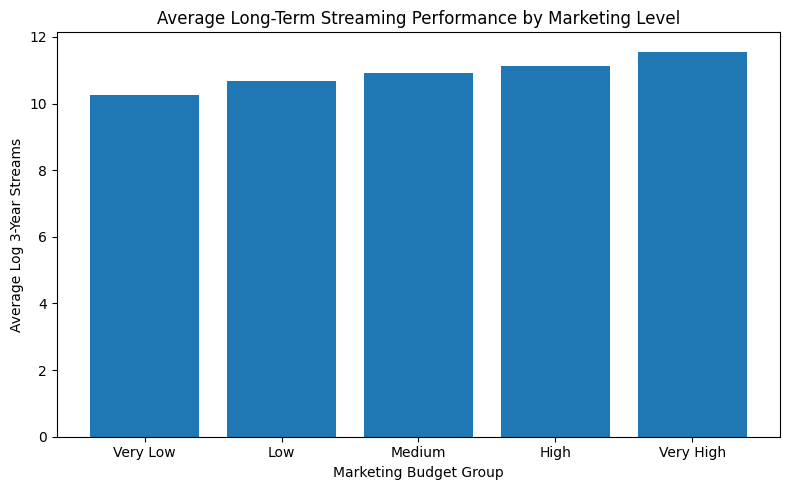

In [5]:
# Marketing correlation
marketing_correlation = df[["marketing_budget", "log_streams_3yr"]].corr().iloc[0, 1]
print("CORRELATION BETWEEN MARKETING BUDGET AND LOG 3-YEAR STREAMS")
print(round(marketing_correlation, 3))

# Marketing quintiles
df["marketing_budget_group"] = pd.qcut(
    df["marketing_budget"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

marketing_summary = (
    df.groupby("marketing_budget_group", observed=True)
      .agg(
          number_of_songs=("track_id", "count"),
          avg_marketing_budget=("marketing_budget", "mean"),
          median_streams_3yr=("streams_3yr", "median"),
          avg_log_streams_3yr=("log_streams_3yr", "mean")
      )
      .reset_index()
)

display(marketing_summary)

plt.figure(figsize=(8, 5))
plt.scatter(df["marketing_budget"], df["log_streams_3yr"], alpha=0.15, s=10)
plt.xlabel("Marketing Budget Index")
plt.ylabel("Log 3-Year Streams")
plt.title("Marketing Budget vs. Long-Term Streaming Performance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    marketing_summary["marketing_budget_group"].astype(str),
    marketing_summary["avg_log_streams_3yr"]
)
plt.xlabel("Marketing Budget Group")
plt.ylabel("Average Log 3-Year Streams")
plt.title("Average Long-Term Streaming Performance by Marketing Level")
plt.tight_layout()
plt.show()


### Step 3 finding

Marketing intensity has a **positive but modest correlation (r = 0.213)** with log three-year streams.

Median three-year streams rise consistently across marketing groups:

- Very Low: **27.3K**
- Low: **41.0K**
- Medium: **52.1K**
- High: **62.9K**
- Very High: **99.0K**

This is an association, not a causal effect.


CORRELATION WITH LOG 3-YEAR STREAMS
marketing_budget              0.213
log_artist_prior_listeners    0.200
featured_artist               0.051
energy                        0.038
danceability                  0.021
valence                       0.005
song_length_sec               0.002
tempo_bpm                    -0.008
acousticness                 -0.010
instrumentalness             -0.028
Name: log_streams_3yr, dtype: float64


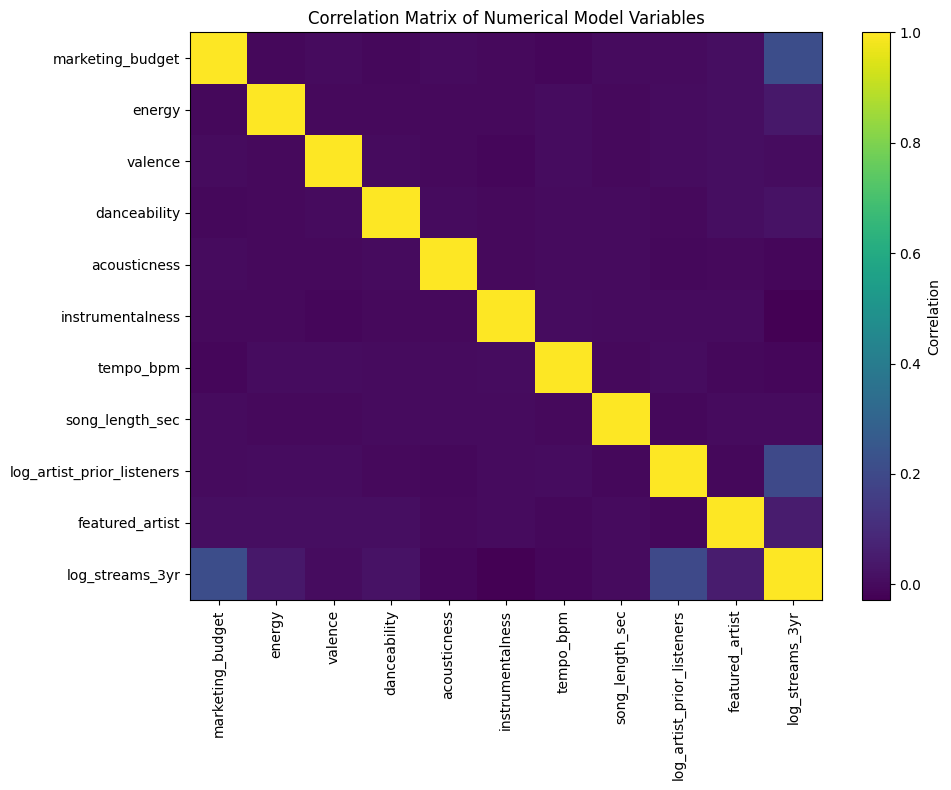

In [6]:
correlation_features = [
    "marketing_budget",
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "instrumentalness",
    "tempo_bpm",
    "song_length_sec",
    "log_artist_prior_listeners",
    "featured_artist",
    "log_streams_3yr"
]

corr_matrix = df[correlation_features].corr()

print("CORRELATION WITH LOG 3-YEAR STREAMS")
target_correlations = (
    corr_matrix["log_streams_3yr"]
    .drop("log_streams_3yr")
    .sort_values(ascending=False)
)
print(target_correlations.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_features)))
ax.set_xticklabels(correlation_features, rotation=90)
ax.set_yticks(range(len(correlation_features)))
ax.set_yticklabels(correlation_features)
ax.set_title("Correlation Matrix of Numerical Model Variables")

fig.colorbar(heatmap, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


## Step 4 — Model Setup

We use only pre-release predictors in the main models.

The data is split into:
- **80% training data**
- **20% test data**
- `random_state = 42` for reproducibility


In [7]:
numeric_features = [
    "marketing_budget",
    "energy",
    "valence",
    "danceability",
    "acousticness",
    "instrumentalness",
    "tempo_bpm",
    "song_length_sec",
    "log_artist_prior_listeners",
    "featured_artist"
]

categorical_features = [
    "genre",
    "label_tier"
]

features = numeric_features + categorical_features

X = df[features]
y = df["log_streams_3yr"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAINING OBSERVATIONS:", len(X_train))
print("TEST OBSERVATIONS:", len(X_test))

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

def evaluate_model(name, y_true, predictions):
    return {
        "Model": name,
        "R2_Log": r2_score(y_true, predictions),
        "MAE_Log": mean_absolute_error(y_true, predictions),
        "RMSE_Log": np.sqrt(mean_squared_error(y_true, predictions))
    }


TRAINING OBSERVATIONS: 36000
TEST OBSERVATIONS: 9000


## Step 5 — Linear Regression Baseline


In [8]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

display(pd.DataFrame([linear_result]).round(4))


,Model,R2_Log,MAE_Log,RMSE_Log
0,Linear Regression,0.1423,1.5459,1.9362


## Step 6 — Random Forest and Gradient Boosting

These models test whether more flexible nonlinear algorithms improve out-of-sample prediction.


In [9]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)
gb_predictions = gradient_boosting_model.predict(X_test)

gb_result = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_predictions
)

display(pd.DataFrame([rf_result, gb_result]).round(4))


,Model,R2_Log,MAE_Log,RMSE_Log
0,Random Forest,0.1108,1.5741,1.9715
1,Gradient Boosting,0.1386,1.5481,1.9404


## Step 7 — Simple Polynomial Regression

A quadratic marketing term is added to test whether the marketing relationship shows evidence of nonlinear saturation or diminishing returns.  
Only `marketing_budget²` is added; we do not create a large polynomial feature space.


In [10]:
X_poly = X.copy()
X_poly["marketing_budget_squared"] = X_poly["marketing_budget"] ** 2

numeric_features_poly = numeric_features + ["marketing_budget_squared"]

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y,
    test_size=0.20,
    random_state=42
)

preprocessor_poly = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

polynomial_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_poly),
        ("model", LinearRegression())
    ]
)

polynomial_model.fit(X_train_poly, y_train_poly)
poly_predictions = polynomial_model.predict(X_test_poly)

poly_result = evaluate_model(
    "Polynomial Regression",
    y_test_poly,
    poly_predictions
)

display(pd.DataFrame([poly_result]).round(4))

poly_feature_names = polynomial_model.named_steps["preprocessor"].get_feature_names_out()
poly_coefficients = polynomial_model.named_steps["model"].coef_

poly_coef_table = pd.DataFrame({
    "Feature": poly_feature_names,
    "Coefficient": poly_coefficients
})

marketing_coefficients = poly_coef_table[
    poly_coef_table["Feature"].str.contains("marketing_budget")
]

print("MARKETING COEFFICIENTS")
display(marketing_coefficients.round(6))


,Model,R2_Log,MAE_Log,RMSE_Log
0,Polynomial Regression,0.1423,1.5459,1.9362


MARKETING COEFFICIENTS


,Feature,Coefficient
9,remainder__marketing_budget,0.289010
19,remainder__marketing_budget_squared,-0.000536


### Polynomial finding

The quadratic marketing coefficient is slightly negative (**−0.000536**), but the Polynomial Regression model does not improve R², MAE, or RMSE relative to Linear Regression.

Therefore, the model provides **no strong evidence of meaningful diminishing marginal returns**.


## Step 8 — Final Model Comparison


In [11]:
results = pd.DataFrame([
    linear_result,
    poly_result,
    gb_result,
    rf_result
])

results = results.sort_values("R2_Log", ascending=False).reset_index(drop=True)

print("MODEL COMPARISON")
display(results.round(4))


MODEL COMPARISON


,Model,R2_Log,MAE_Log,RMSE_Log
0,Polynomial Regression,0.1423,1.5459,1.9362
1,Linear Regression,0.1423,1.5459,1.9362
2,Gradient Boosting,0.1386,1.5481,1.9404
3,Random Forest,0.1108,1.5741,1.9715


### Model comparison finding

Linear Regression and Polynomial Regression achieve the best test performance with **R² ≈ 0.1423**.  
Gradient Boosting is slightly weaker and Random Forest performs worst among the four tested models.

The simpler Linear Regression is retained as the main interpretable model because the more complex alternatives do not improve predictive performance.


## Step 9 — Marketing Coefficient and Conditional Association


In [12]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

marketing_row = coef_table[
    coef_table["Feature"].str.contains("marketing_budget")
]

marketing_coefficient = marketing_row["Coefficient"].iloc[0]
marketing_percent_effect = (np.exp(marketing_coefficient) - 1) * 100

print("MARKETING COEFFICIENT")
display(marketing_row)

print("ESTIMATED EFFECT OF +1 MARKETING INDEX UNIT")
print(round(marketing_percent_effect, 2), "%")


MARKETING COEFFICIENT


,Feature,Coefficient
9,remainder__marketing_budget,0.286267


ESTIMATED EFFECT OF +1 MARKETING INDEX UNIT
33.14 %


### Marketing coefficient finding

Holding the other model variables constant, a one-unit increase in the relative marketing-intensity index is associated with approximately **33.1% higher predicted three-year streams**.

This is a model-based association and should **not** be interpreted as a causal return on marketing investment.


## Step 10 — Permutation Feature Importance


In [13]:
# Linear Regression permutation importance
linear_perm = permutation_importance(
    linear_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

linear_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": linear_perm.importances_mean
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("LINEAR REGRESSION PERMUTATION FEATURE IMPORTANCE")
display(linear_importance.round(4))


LINEAR REGRESSION PERMUTATION FEATURE IMPORTANCE


,Feature,Importance
0,label_tier,0.1101
1,log_artist_prior_listeners,0.0807
2,marketing_budget,0.0566
3,featured_artist,0.0027
4,energy,0.0019
5,instrumentalness,0.0015
6,danceability,0.0008
7,genre,0.0003
8,tempo_bpm,0.0002
9,acousticness,0.0002


RANDOM FOREST PERMUTATION FEATURE IMPORTANCE


,Feature,Importance
0,label_tier,0.1107
1,log_artist_prior_listeners,0.0810
2,marketing_budget,0.0581
3,song_length_sec,0.0054
4,featured_artist,0.0034
5,energy,0.0029
6,instrumentalness,0.0013
7,valence,0.0011
8,genre,0.0010
9,danceability,0.0001


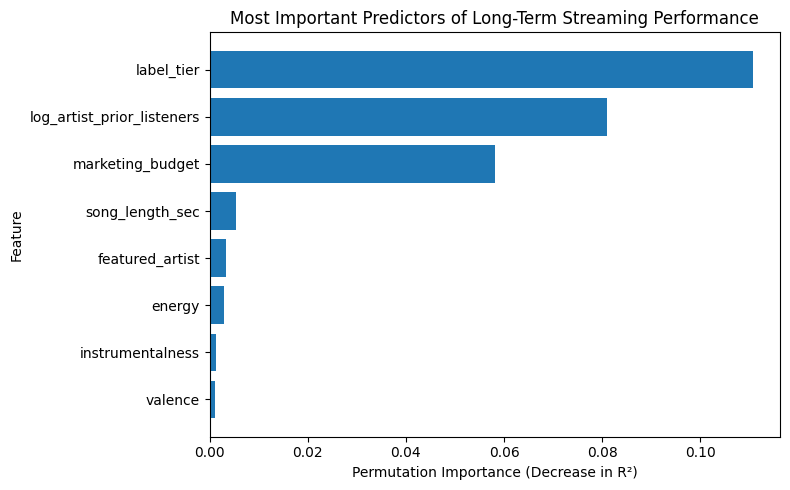

In [14]:
# Random Forest permutation importance
rf_permutation = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

rf_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_permutation.importances_mean
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("RANDOM FOREST PERMUTATION FEATURE IMPORTANCE")
display(rf_importance.round(4))

top_features = rf_importance.head(8).sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Permutation Importance (Decrease in R²)")
plt.ylabel("Feature")
plt.title("Most Important Predictors of Long-Term Streaming Performance")
plt.tight_layout()
plt.show()


### Feature-importance finding

Both Linear Regression and Random Forest identify the same three dominant predictors:

1. **Label tier**
2. **Prior artist popularity**
3. **Marketing budget**

Marketing therefore remains a top-three predictor across different modelling approaches.  
Individual audio characteristics contribute much less predictive information.


## Step 11 — Actual vs. Predicted and Residuals


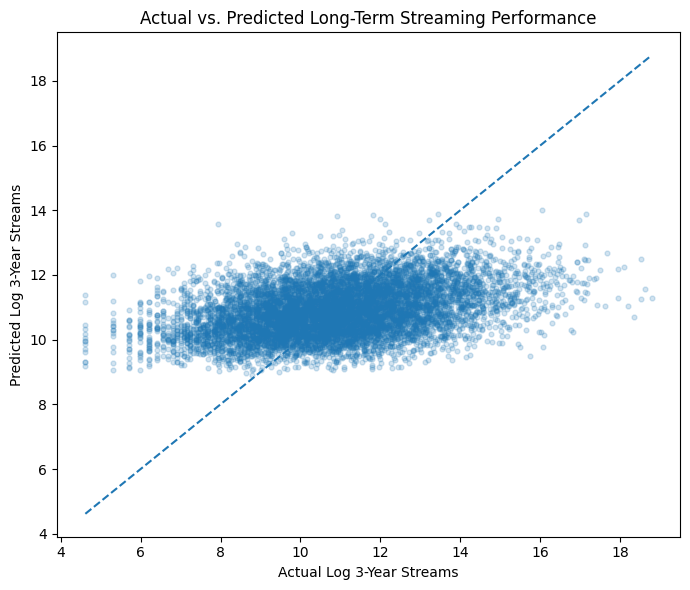

RESIDUAL SUMMARY
count    9000.000
mean       -0.026
std         1.936
min        -6.779
25%        -1.342
50%        -0.076
75%         1.263
max         7.638
dtype: float64

MEAN RESIDUAL: -0.0263


In [15]:
prediction_results = pd.DataFrame({
    "Actual_Log_Streams": y_test,
    "Predicted_Log_Streams": linear_predictions
})

plt.figure(figsize=(7, 6))
plt.scatter(
    prediction_results["Actual_Log_Streams"],
    prediction_results["Predicted_Log_Streams"],
    alpha=0.2,
    s=12
)

minimum = min(
    prediction_results["Actual_Log_Streams"].min(),
    prediction_results["Predicted_Log_Streams"].min()
)

maximum = max(
    prediction_results["Actual_Log_Streams"].max(),
    prediction_results["Predicted_Log_Streams"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Log 3-Year Streams")
plt.ylabel("Predicted Log 3-Year Streams")
plt.title("Actual vs. Predicted Long-Term Streaming Performance")
plt.tight_layout()
plt.show()

residuals = (
    prediction_results["Actual_Log_Streams"]
    - prediction_results["Predicted_Log_Streams"]
)

print("RESIDUAL SUMMARY")
print(residuals.describe().round(3))

print("\nMEAN RESIDUAL:", round(residuals.mean(), 4))


### Residual finding

The mean residual is close to zero, indicating little overall directional bias.  
However, the model struggles with extreme outcomes and tends to pull unusually successful songs toward more typical predictions. This is consistent with the modest R².


## Step 12 — Marketing Response Curve

We hold the other features at representative values and vary only marketing intensity within the central observed range.  
Predictions come from the Polynomial Regression model so that any curvature can appear.


MARKETING RANGE USED
0.06 to 5.7

SELECTED MARKETING RESPONSE POINTS


,marketing_budget,predicted_log_streams,predicted_streams_3yr
0,0.06,9.97,21398.31
11,0.69,10.15,25640.72
22,1.31,10.33,30711.26
33,1.94,10.51,36769.01
44,2.57,10.69,44003.08
55,3.19,10.87,52638.22
66,3.82,11.05,62941.38
77,4.45,11.23,75229.54
88,5.07,11.41,89878.87
99,5.70,11.58,107335.64


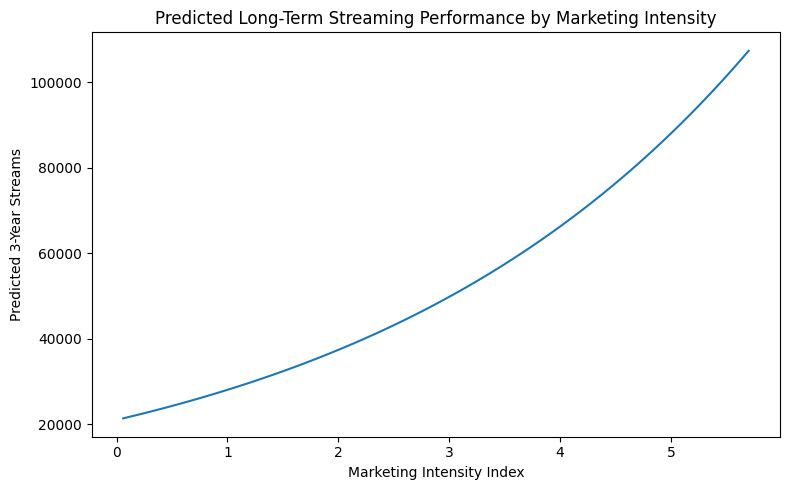

In [16]:
marketing_min = df["marketing_budget"].quantile(0.01)
marketing_max = df["marketing_budget"].quantile(0.99)

marketing_grid = np.linspace(marketing_min, marketing_max, 100)

response_data = pd.DataFrame()

for feature in numeric_features:
    response_data[feature] = np.repeat(
        df[feature].median(),
        len(marketing_grid)
    )

for feature in categorical_features:
    response_data[feature] = np.repeat(
        df[feature].mode()[0],
        len(marketing_grid)
    )

response_data["marketing_budget"] = marketing_grid
response_data["marketing_budget_squared"] = response_data["marketing_budget"] ** 2
response_data = response_data[X_poly.columns]

predicted_log_streams = polynomial_model.predict(response_data)
predicted_streams = np.expm1(predicted_log_streams)

marketing_response = pd.DataFrame({
    "marketing_budget": marketing_grid,
    "predicted_log_streams": predicted_log_streams,
    "predicted_streams_3yr": predicted_streams
})

print("MARKETING RANGE USED")
print(round(marketing_min, 3), "to", round(marketing_max, 3))

selected_indices = np.linspace(
    0,
    len(marketing_response) - 1,
    10,
    dtype=int
)

print("\nSELECTED MARKETING RESPONSE POINTS")
display(marketing_response.iloc[selected_indices].round(2))

plt.figure(figsize=(8, 5))
plt.plot(
    marketing_response["marketing_budget"],
    marketing_response["predicted_streams_3yr"]
)
plt.xlabel("Marketing Intensity Index")
plt.ylabel("Predicted 3-Year Streams")
plt.title("Predicted Long-Term Streaming Performance by Marketing Intensity")
plt.tight_layout()
plt.show()


### Marketing-response finding

Predicted long-term streams rise consistently across the observed marketing range.  
The response curve shows only very weak flattening and does not provide strong evidence of saturation.


## Step 13 — One-Unit Marketing Increase

We compare predicted streams for marketing index values 2, 3, 4, and 5.


In [17]:
base_profile = {}

for feature in numeric_features:
    base_profile[feature] = df[feature].median()

for feature in categorical_features:
    base_profile[feature] = df[feature].mode()[0]

marketing_levels = [2, 3, 4, 5]
rows = []

for m in marketing_levels:
    row = base_profile.copy()
    row["marketing_budget"] = m
    row["marketing_budget_squared"] = m ** 2
    rows.append(row)

marketing_test = pd.DataFrame(rows)
marketing_test = marketing_test[X_poly.columns]

predicted_log = polynomial_model.predict(marketing_test)
predicted_streams = np.expm1(predicted_log)

marketing_test_results = pd.DataFrame({
    "marketing_budget": marketing_levels,
    "predicted_log_streams": predicted_log,
    "predicted_streams_3yr": predicted_streams
})

print("PREDICTED STREAMS AT SELECTED MARKETING LEVELS")
display(marketing_test_results.round(2))

increment_rows = []

for i in range(len(marketing_test_results) - 1):
    from_level = marketing_test_results.loc[i, "marketing_budget"]
    to_level = marketing_test_results.loc[i + 1, "marketing_budget"]

    from_streams = marketing_test_results.loc[i, "predicted_streams_3yr"]
    to_streams = marketing_test_results.loc[i + 1, "predicted_streams_3yr"]

    absolute_change = to_streams - from_streams
    percent_change = (absolute_change / from_streams) * 100

    increment_rows.append({
        "from_marketing": from_level,
        "to_marketing": to_level,
        "predicted_streams_before": from_streams,
        "predicted_streams_after": to_streams,
        "absolute_change": absolute_change,
        "percent_change": percent_change
    })

increment_table = pd.DataFrame(increment_rows)

print("ONE-UNIT MARKETING INCREASE TABLE")
display(increment_table.round(2))


PREDICTED STREAMS AT SELECTED MARKETING LEVELS


,marketing_budget,predicted_log_streams,predicted_streams_3yr
0,2,10.53,37407.44
1,3,10.82,49809.59
2,4,11.10,66252.44
3,5,11.39,88028.83


ONE-UNIT MARKETING INCREASE TABLE


,from_marketing,to_marketing,predicted_streams_before,predicted_streams_after,absolute_change,percent_change
0,2,3,37407.44,49809.59,12402.15,33.15
1,3,4,49809.59,66252.44,16442.85,33.01
2,4,5,66252.44,88028.83,21776.39,32.87


### Diminishing-returns conclusion

The predicted percentage gain from each one-unit marketing increase remains almost constant:

- 2 → 3: about **33.15%**
- 3 → 4: about **33.01%**
- 4 → 5: about **32.87%**

The decline is extremely small, while the absolute predicted stream gain becomes larger.

**Conclusion:** The analysis provides **no strong evidence of meaningful diminishing marginal returns within the observed marketing range**.


## Step 14 — Marketing × Audio Interactions

We test whether marketing intensity behaves differently depending on two audio features: `energy` and `instrumentalness`.

The interaction terms are:
- `marketing_budget × energy`
- `marketing_budget × instrumentalness`


In [18]:
X_interaction = X_poly.copy()

X_interaction["marketing_x_energy"] = (
    X_interaction["marketing_budget"] * X_interaction["energy"]
)

X_interaction["marketing_x_instrumentalness"] = (
    X_interaction["marketing_budget"] * X_interaction["instrumentalness"]
)

X_train_int, X_test_int, y_train_int, y_test_int = train_test_split(
    X_interaction,
    y,
    test_size=0.20,
    random_state=42
)

preprocessor_interaction = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

interaction_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_interaction),
        ("model", LinearRegression())
    ]
)

interaction_model.fit(X_train_int, y_train_int)
interaction_predictions = interaction_model.predict(X_test_int)

interaction_result = evaluate_model(
    "Marketing-Audio Interaction",
    y_test_int,
    interaction_predictions
)

print("INTERACTION MODEL PERFORMANCE")
display(pd.DataFrame([interaction_result]).round(4))

interaction_feature_names = (
    interaction_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

interaction_coefficients = (
    interaction_model
    .named_steps["model"]
    .coef_
)

interaction_coef_table = pd.DataFrame({
    "Feature": interaction_feature_names,
    "Coefficient": interaction_coefficients
})

selected_interactions = interaction_coef_table[
    interaction_coef_table["Feature"].str.contains(
        "marketing_x_energy|marketing_x_instrumentalness"
    )
]

print("AUDIO INTERACTION COEFFICIENTS")
display(selected_interactions.round(6))

comparison = pd.DataFrame([
    poly_result,
    interaction_result
])

print("INTERACTION MODEL COMPARISON")
display(
    comparison
    .sort_values("R2_Log", ascending=False)
    .round(4)
)


INTERACTION MODEL PERFORMANCE


,Model,R2_Log,MAE_Log,RMSE_Log
0,Marketing-Audio Interaction,0.1423,1.546,1.9363


AUDIO INTERACTION COEFFICIENTS


,Feature,Coefficient
20,remainder__marketing_x_energy,-0.001082
21,remainder__marketing_x_instrumentalness,0.003262


INTERACTION MODEL COMPARISON


,Model,R2_Log,MAE_Log,RMSE_Log
0,Polynomial Regression,0.1423,1.5459,1.9362
1,Marketing-Audio Interaction,0.1423,1.5460,1.9363


### Interaction finding

Adding Marketing × Energy and Marketing × Instrumentalness does not improve predictive performance.

The interaction coefficients are very small:
- Marketing × Energy: approximately **−0.0011**
- Marketing × Instrumentalness: approximately **+0.0033**

Therefore, there is **no meaningful evidence that the marketing relationship differs substantially according to these selected audio characteristics**.


## Step 15 — Audio × Marketing Response Curves

To make the interaction analysis easier to interpret visually, we compare the model-predicted marketing response at **low (25th percentile)**, **medium (median)**, and **high (75th percentile)** values of the two selected audio characteristics:

- Energy
- Instrumentalness

The curves are based on the interaction model. All other predictors are held at representative values.

This is a predictive comparison rather than a causal analysis.


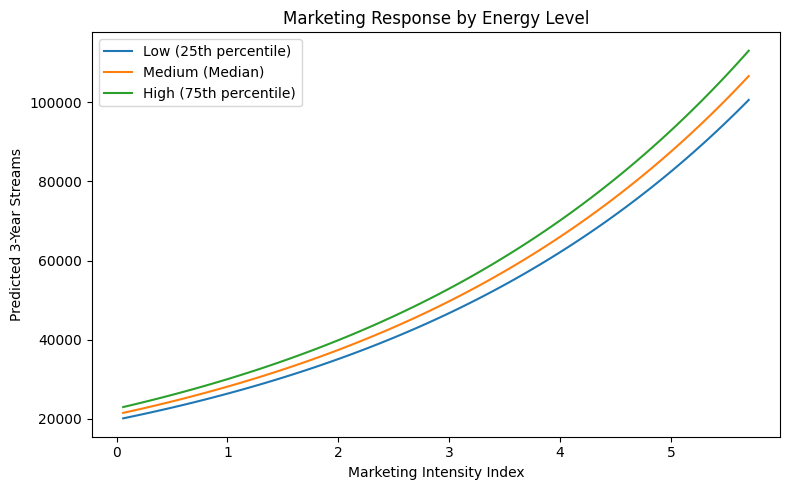

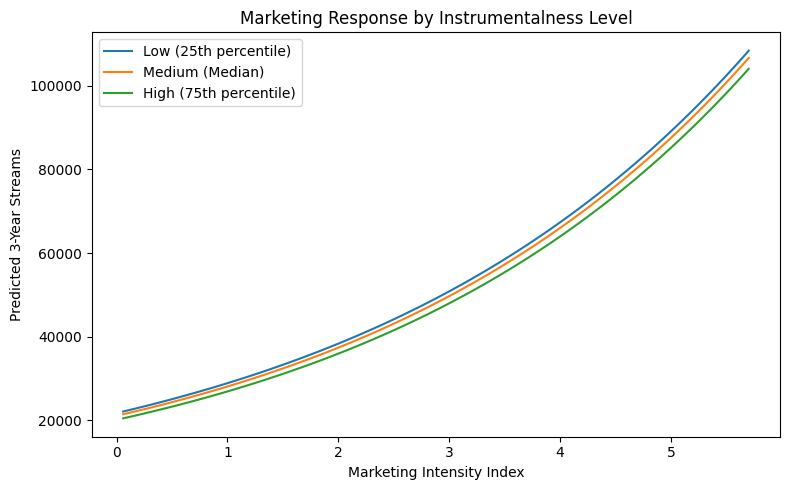

AUDIO INTERACTION CURVE SAMPLE


,audio_feature,audio_level,audio_value,min_predicted_streams,max_predicted_streams
0,energy,High (75th percentile),7.35,22927.44,113074.37
1,energy,Low (25th percentile),4.65,20069.43,100624.04
2,energy,Medium (Median),6.00,21450.89,106667.71
3,instrumentalness,High (75th percentile),2.67,20472.98,104063.62
4,instrumentalness,Low (25th percentile),0.71,22107.01,108383.70
5,instrumentalness,Medium (Median),1.48,21450.89,106667.71


In [19]:
# -----------------------------------
# AUDIO × MARKETING RESPONSE CURVES
# 25th percentile / Median / 75th percentile
# -----------------------------------

audio_features_to_plot = [
    "energy",
    "instrumentalness"
]

marketing_grid_interaction = np.linspace(
    df["marketing_budget"].quantile(0.01),
    df["marketing_budget"].quantile(0.99),
    100
)

audio_interaction_curve_rows = []

for audio_feature in audio_features_to_plot:

    audio_levels = {
        "Low (25th percentile)": df[audio_feature].quantile(0.25),
        "Medium (Median)": df[audio_feature].median(),
        "High (75th percentile)": df[audio_feature].quantile(0.75)
    }

    plt.figure(figsize=(8, 5))

    for level_name, level_value in audio_levels.items():

        curve_data = pd.DataFrame(
            index=range(len(marketing_grid_interaction))
        )

        # Hold numerical controls at their medians
        for feature in numeric_features:
            curve_data[feature] = df[feature].median()

        # Hold categorical controls at their modes
        for feature in categorical_features:
            curve_data[feature] = df[feature].mode()[0]

        # Vary marketing intensity
        curve_data["marketing_budget"] = marketing_grid_interaction

        # Set selected audio characteristic
        curve_data[audio_feature] = level_value

        # Recreate model terms
        curve_data["marketing_budget_squared"] = (
            curve_data["marketing_budget"] ** 2
        )

        curve_data["marketing_x_energy"] = (
            curve_data["marketing_budget"]
            * curve_data["energy"]
        )

        curve_data["marketing_x_instrumentalness"] = (
            curve_data["marketing_budget"]
            * curve_data["instrumentalness"]
        )

        # Match training column order
        curve_data = curve_data[X_interaction.columns]

        predicted_log = interaction_model.predict(curve_data)
        predicted_streams = np.expm1(predicted_log)

        plt.plot(
            marketing_grid_interaction,
            predicted_streams,
            label=level_name
        )

        for marketing_value, predicted_value in zip(
            marketing_grid_interaction,
            predicted_streams
        ):
            audio_interaction_curve_rows.append({
                "audio_feature": audio_feature,
                "audio_level": level_name,
                "audio_value": level_value,
                "marketing_budget": marketing_value,
                "predicted_streams_3yr": predicted_value
            })

    plt.xlabel("Marketing Intensity Index")
    plt.ylabel("Predicted 3-Year Streams")
    plt.title(
        f"Marketing Response by {audio_feature.replace('_', ' ').title()} Level"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


audio_interaction_curves = pd.DataFrame(
    audio_interaction_curve_rows
)

print("AUDIO INTERACTION CURVE SAMPLE")
display(
    audio_interaction_curves
    .groupby(["audio_feature", "audio_level"], as_index=False)
    .agg(
        audio_value=("audio_value", "first"),
        min_predicted_streams=("predicted_streams_3yr", "min"),
        max_predicted_streams=("predicted_streams_3yr", "max")
    )
    .round(2)
)


### Audio interaction curve finding

The low-, medium-, and high-level response curves remain broadly similar in shape.  
This visual result is consistent with the interaction-model metrics: **energy and instrumentalness do not meaningfully change the relationship between marketing intensity and predicted long-term streams**.

The curves may differ slightly in their overall predicted level, but there is no strong evidence that the *marketing slope itself* changes substantially across these audio levels.


# IDIL — MACHINE LEARNING FINDINGS

## 1. Objective

The machine learning analysis examines how marketing intensity is associated with long-term streaming performance, whether the relationship shows evidence of diminishing marginal returns, which pre-release factors are most important for prediction, and whether selected audio characteristics modify the marketing relationship.

## 2. Data Preprocessing

- The dataset contains **45,000 songs and 21 variables**.
- No missing values or duplicated track IDs were identified.
- `streams_3yr` was strongly right-skewed and was transformed using `log1p()`, reducing skewness from **53.22 to 0.15**.
- `artist_prior_monthly_listeners` was also log-transformed, reducing skewness from **40.72 to 0.12**.
- Post-release variables (`first_month_streams`, `playlist_adds_first_month`, `editorial_playlist`, and `tiktok_virality`) were excluded from the main model to avoid using information that becomes available after release.
- `marketing_budget` is interpreted as a **relative marketing-intensity index**, not as monetary expenditure.

## 3. Models Used

Four regression approaches were compared:

- Linear Regression
- Polynomial Regression with `marketing_budget²`
- Random Forest Regression
- Gradient Boosting Regression

The dataset was split into **80% training data (36,000 songs)** and **20% test data (9,000 songs)** using `random_state=42`.

## 4. Model Performance

| Model | R² (log target) | MAE | RMSE |
|---|---:|---:|---:|
| Linear Regression | **0.1423** | **1.5459** | **1.9362** |
| Polynomial Regression | **0.1423** | **1.5459** | **1.9362** |
| Gradient Boosting | 0.1386 | 1.5481 | 1.9404 |
| Random Forest | 0.1108 | 1.5741 | 1.9715 |

Linear Regression achieved the best overall test performance while remaining the simplest and most interpretable model. The R² of approximately **0.142** means that the pre-release predictors explain about **14.2% of the variation in log-transformed three-year streaming performance**.

## 5. Key Predictors

Random Forest permutation importance identified the three strongest predictors as:

1. **Label tier — 0.1107**
2. **Prior artist popularity — 0.0810**
3. **Marketing budget — 0.0581**

The same three variables were also dominant in the Linear Regression permutation-importance analysis. Individual audio characteristics showed substantially lower predictive importance.

## 6. Marketing Effect

The Linear Regression marketing coefficient was approximately **0.286**. Because the target is log-transformed, this corresponds to approximately **33.1% higher predicted three-year streams for a one-unit increase in the marketing-intensity index**, holding the included model variables constant.

This is a **conditional model association**, not a causal estimate or financial ROI.

## 7. Diminishing Returns

A quadratic marketing term was added to test for nonlinear saturation.

- Linear marketing coefficient: approximately **0.2890**
- Quadratic marketing coefficient: approximately **−0.000536**
- Polynomial Regression did **not** improve R², MAE, or RMSE.

Predicted one-unit marketing increases were approximately:

- 2 → 3: **+33.15%**
- 3 → 4: **+33.01%**
- 4 → 5: **+32.87%**

The decline is extremely small, while the absolute predicted stream gain becomes larger. Therefore, the analysis provides **no strong evidence of meaningful diminishing marginal returns within the observed marketing range**.

## 8. Audio × Marketing Interactions

Interactions between marketing intensity and **energy** and **instrumentalness** were tested.

- Marketing × Energy coefficient: approximately **−0.0011**
- Marketing × Instrumentalness coefficient: approximately **+0.0033**
- Interaction-model R² remained approximately **0.1423**.

Low (25th percentile), medium (median), and high (75th percentile) response curves were also compared. Their shapes remained broadly similar.

Therefore, there is **no meaningful evidence that energy or instrumentalness substantially changes the marketing–streaming relationship**.

## 9. Main Conclusions

- Higher marketing intensity is consistently associated with higher predicted long-term streaming performance.
- Marketing is one of the **three strongest predictors**, together with label tier and prior artist popularity.
- A one-unit increase in the relative marketing-intensity index is associated with roughly **33% higher predicted three-year streams**, conditional on the included features.
- More complex models did not outperform the simpler Linear Regression model.
- The analysis found **no strong evidence of meaningful diminishing marketing returns** across the observed range.
- The selected audio characteristics did not meaningfully modify the marketing relationship.
- Pre-release characteristics provide measurable predictive information, but most variation in long-term music success remains unexplained.

## 10. Limitations

- `marketing_budget` is a relative index rather than actual monetary spend.
- Predictive relationships and regression coefficients do **not establish causality**.
- Post-release developments such as playlist exposure, TikTok virality, audience response, and word of mouth are deliberately excluded from the main pre-release model.
- The model explains approximately 14% of variation in the log target and should not be interpreted as a precise hit-prediction system.
- Conclusions about diminishing returns apply only within the observed marketing range.
- The audio interaction analysis is limited to energy and instrumentalness.


## Final Team Handoff

The notebook creates clean CSV outputs for the rest of the group:

### For Can — Visualization / Streamlit
- `model_performance.csv`
- `feature_importance.csv`
- `marketing_response_curve.csv`
- `marginal_marketing_return.csv`
- `audio_marketing_interactions.csv`
- `audio_marketing_interaction_curves.csv`

### For Jakob — Statistical Analysis
The most relevant ML results to compare with the statistical analysis are:
- Marketing correlation with log three-year streams: **0.213**
- Linear Regression marketing coefficient: approximately **0.286**
- Approximate conditional association for a +1 marketing-index unit: **+33.1%**
- Quadratic marketing coefficient: approximately **−0.000536**
- Final conclusion: **no strong evidence of meaningful diminishing marginal returns**


In [20]:
# -----------------------------------
# DASHBOARD EXPORT (data contract) -> results/ml_*
# The Streamlit app only reads these files; it does not fit any model itself.
# -----------------------------------
import json
from datetime import datetime, timezone
from pathlib import Path

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

GROUPS = {
    "marketing_budget": "distribution", "label_tier": "label", "genre": "genre",
    "log_artist_prior_listeners": "artist", "featured_artist": "artist",
    "energy": "audio", "valence": "audio", "danceability": "audio", "acousticness": "audio",
    "instrumentalness": "audio", "tempo_bpm": "audio", "song_length_sec": "audio",
}

# ---- existing handoff files (renamed with ml_ prefix) ----
results.to_csv(RESULTS / "ml_model_performance.csv", index=False)
marketing_response.to_csv(RESULTS / "ml_marketing_response_curve.csv", index=False)
increment_table.to_csv(RESULTS / "ml_marginal_marketing_return.csv", index=False)
selected_interactions.to_csv(RESULTS / "ml_audio_marketing_interactions.csv", index=False)
audio_interaction_curves.to_csv(RESULTS / "ml_audio_marketing_interaction_curves.csv", index=False)

# ---- feature importance: linear AND random forest ----
fi = pd.concat([linear_importance.assign(model="Linear Regression"),
                rf_importance.assign(model="Random Forest")], ignore_index=True)
fi = fi.rename(columns={"Feature": "feature", "Importance": "importance"})
fi["group"] = fi["feature"].map(GROUPS)
fi[["model", "feature", "importance", "group"]].to_csv(RESULTS / "ml_feature_importance.csv", index=False)

# ---- test-set predictions of the linear model ----
pd.DataFrame({"actual_log": y_test.values, "predicted_log": linear_predictions,
              "residual": y_test.values - linear_predictions}
             ).to_csv(RESULTS / "ml_test_predictions.csv", index=False)

# ---- scenario grid for the Low / Medium / High selectors (polynomial model) ----
LEVELS = {"Low": 0.25, "Medium": 0.50, "High": 0.75}
sc_grid = np.linspace(df["marketing_budget"].quantile(0.01), df["marketing_budget"].quantile(0.99), 100)
frames = []
for tier in sorted(df["label_tier"].unique()):
    for l_name, l_q in LEVELS.items():
        for e_name, e_q in LEVELS.items():
            d = pd.DataFrame({f: np.repeat(df[f].median(), len(sc_grid)) for f in numeric_features})
            d["genre"] = df["genre"].mode()[0]
            d["label_tier"] = tier
            d["log_artist_prior_listeners"] = df["log_artist_prior_listeners"].quantile(l_q)
            d["energy"] = df["energy"].quantile(e_q)
            d["marketing_budget"] = sc_grid
            d["marketing_budget_squared"] = sc_grid ** 2
            p = polynomial_model.predict(d[X_poly.columns])
            frames.append(pd.DataFrame({
                "marketing_budget": sc_grid, "label_tier": tier,
                "listeners_level": l_name,
                "listeners_value": np.expm1(df["log_artist_prior_listeners"].quantile(l_q)),
                "energy_level": e_name, "energy_value": df["energy"].quantile(e_q),
                "predicted_log_streams": p, "predicted_streams": np.expm1(p),
            }))
pd.concat(frames, ignore_index=True).to_csv(RESULTS / "ml_scenario_grid.csv", index=False)

# ---- metadata ----
json.dump({
    "notebook": "idil_I2pdp_final(2).ipynb",
    "generated_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "target": "log1p(streams_3yr)",
    "split": "80/20 train/test, random_state=42",
    "includes_tiktok": False,
    "excluded_post_release": post_release_variables,
    "scenario_grid_model": "Polynomial Regression (marketing + marketing^2); other features at median / mode "
                           "(genre = most common), levels = 25th / 50th / 75th percentile",
    "notes": "TikTok virality, playlist adds, editorial playlist and first-month streams are excluded "
             "because they are only known after release.",
}, open(RESULTS / "ml_metadata.json", "w"), indent=2)

print("Exported:", sorted(p.name for p in RESULTS.glob("ml_*")))


Exported: ['ml_audio_marketing_interaction_curves.csv', 'ml_audio_marketing_interactions.csv', 'ml_feature_importance.csv', 'ml_marginal_marketing_return.csv', 'ml_marketing_response_curve.csv', 'ml_metadata.json', 'ml_model_performance.csv', 'ml_scenario_grid.csv', 'ml_test_predictions.csv']
